In [423]:
from datetime import datetime, timezone, timedelta
from orbit import simulation_config, propagate_orbit
import constants as const
from utils import conversions as conv
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import numpy as np
import math

# Test 1 - VLEO Baseline

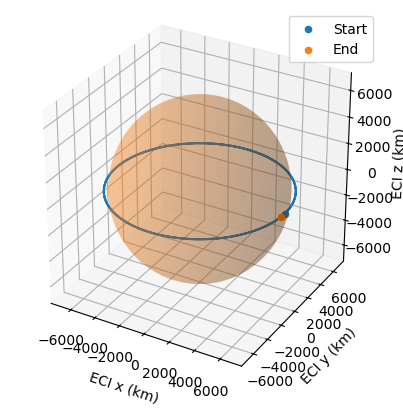

Expected period [min]:  90.51945583787281
Observed period [min]:  90.5


In [424]:
# Setting up constants and initial conditions
propagation_method = "cowell"
mu = const.EARTH_MU_m3_s2
r0 = const.EARTH_RADIUS_EQ_m + 300000
v0 = math.sqrt(mu / r0)

x0 = np.array([
    r0, 0, 0,
    0, v0, 0
])

duration = 180
steps_per_min = 10
t0 = datetime(2026, 9, 4, 0, 0, 0,tzinfo=timezone.utc)
tf = t0 + timedelta(minutes=duration)
config = simulation_config(
    t0=t0,
    tf=tf,
    time_steps=duration*steps_per_min,
    propagator_method=propagation_method,
    x0=x0,
    drag=False,
    J2=False
)

# running propagation
states = propagate_orbit(config)
x = states[0, :] / 1000
y = states[1, :] / 1000
z = states[2, :] / 1000

# Plotting
fig = plt.figure()
ax = fig.add_subplot(111, projection="3d")

# Plotting orbit
ax.plot(x, y, z)
ax.scatter(x[0], y[0], z[0],label="Start")
ax.scatter(x[-1], y[-1], z[-1], label="End")

# Drawing up the earth
R_earth = const.EARTH_RADIUS_EQ_m / 1000
longitudes = np.linspace(0, 2 * np.pi, 100)
latitudes = np.linspace(0, np.pi, 100)
x_earth = R_earth * np.outer(np.cos(longitudes), np.sin(latitudes))
y_earth = R_earth * np.outer(np.sin(longitudes), np.sin(latitudes))
z_earth = R_earth * np.outer(np.ones_like(longitudes), np.cos(latitudes))
ax.plot_surface(x_earth, y_earth, z_earth, alpha=0.25)

ax.set_xlabel("ECI x (km)")
ax.set_ylabel("ECI y (km)")
ax.set_zlabel("ECI z (km)")
ax.set_box_aspect([1, 1, 1])
ax.legend()
plt.show()

expected_T = math.sqrt(4 * (math.pi)**2 * r0**3 / mu) / 60
print("Expected period [min]: ", expected_T)

min_dist = 10**10
observed_T = 0.0
buff = 10

for ind in range(int((expected_T - buff) * steps_per_min), int((expected_T + buff) * steps_per_min)):
    if abs(x[ind] - r0/1000) < min_dist:
        observed_T = ind / steps_per_min
        min_dist = abs(x[ind] - r0/1000)
        
print("Observed period [min]: ", observed_T)

# Test 2 - HEO Baseline

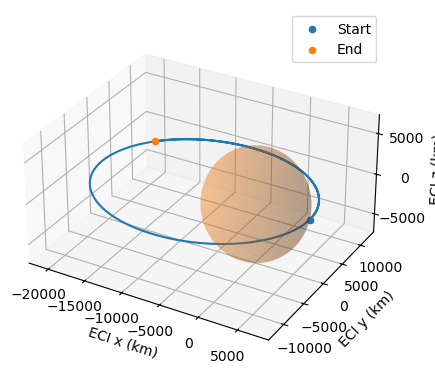

In [425]:
# Setting up constants and initial conditions
propagation_method = "cowell"
mu = const.EARTH_MU_m3_s2
r0 = const.EARTH_RADIUS_EQ_m + 500000
v0 = math.sqrt(1.5 * mu / r0)

x0 = np.array([
    r0, 0, 0,
    0, v0, 0
])

duration = 360
steps_per_min = 10
t0 = datetime(2026, 9, 4, 0, 0, 0,tzinfo=timezone.utc)
tf = t0 + timedelta(minutes=duration)
config = simulation_config(
    t0=t0,
    tf=tf,
    time_steps=duration*steps_per_min,
    propagator_method=propagation_method,
    x0=x0,
    drag=False,
    J2=False
)

# running propagation
states = propagate_orbit(config)
x = states[0, :] / 1000
y = states[1, :] / 1000
z = states[2, :] / 1000

# Plotting
fig = plt.figure()
ax = fig.add_subplot(111, projection="3d")

# Plotting orbit
# plt.axis('equal')
ax.plot(x, y, z)
ax.scatter(x[0], y[0], z[0],label="Start")
ax.scatter(x[-1], y[-1], z[-1], label="End")

# Drawing up the earth
R_earth = const.EARTH_RADIUS_EQ_m / 1000
longitudes = np.linspace(0, 2 * np.pi, 100)
latitudes = np.linspace(0, np.pi, 100)
x_earth = R_earth * np.outer(np.cos(longitudes), np.sin(latitudes))
y_earth = R_earth * np.outer(np.sin(longitudes), np.sin(latitudes))
z_earth = R_earth * np.outer(np.ones_like(longitudes), np.cos(latitudes))
ax.plot_surface(x_earth, y_earth, z_earth, alpha=0.25)

ax.set_xlabel("ECI x (km)")
ax.set_ylabel("ECI y (km)")
ax.set_zlabel("ECI z (km)")

ax.xaxis.set_major_locator(ticker.MultipleLocator(5000.0))
ax.yaxis.set_major_locator(ticker.MultipleLocator(5000.0)) 
ax.zaxis.set_major_locator(ticker.MultipleLocator(5000.0))  

ax.set_box_aspect([1.2, 1, 0.6])

ax.legend()

plt.show()

# Test 3 - Molniya Orbit Effects

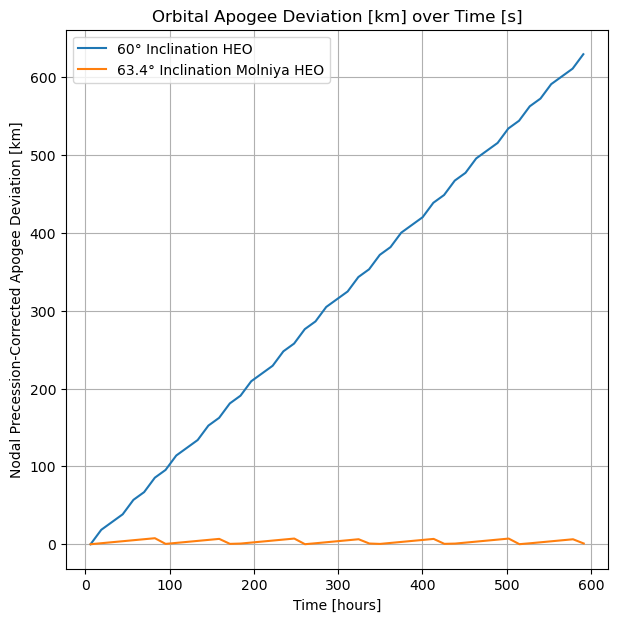

In [426]:
# Setting up constants and initial conditions
propagation_method = "cowell"
mu = const.EARTH_MU_m3_s2
MOLNIYA_INC = np.deg2rad(63.435)
J2 = 1.08262668e-3
r0 = const.EARTH_RADIUS_EQ_m + 500000
v0 = math.sqrt(1.75 * mu / r0)

x0_reg = np.array([
    r0 * math.cos(math.pi/3), 0, -r0 * math.sin(math.pi/3),
    0, v0, 0
])

x0_molniya = np.array([
    r0 * math.cos(MOLNIYA_INC), 0, -r0 * math.sin(MOLNIYA_INC),
    0, v0, 0
])

duration = 60 * 600
steps_per_min = 10
t0 = datetime(2026, 9, 4, 0, 0, 0,tzinfo=timezone.utc)
tf = t0 + timedelta(minutes=duration)

config_reg = simulation_config(
    t0=t0,
    tf=tf,
    time_steps=duration*steps_per_min,
    propagator_method=propagation_method,
    x0=x0_reg,
    drag=False,
    J2=True
)

config_molniya = simulation_config(
    t0=t0,
    tf=tf,
    time_steps=duration*steps_per_min,
    propagator_method=propagation_method,
    x0=x0_molniya,
    drag=False,
    J2=True
)

# running propagation
states_reg = propagate_orbit(config_reg)
states_molniya = propagate_orbit(config_molniya)

r_vecs_reg = np.transpose(states_reg[:3, :])
r_vecs_molniya = np.transpose(states_molniya[:3, :])

norm_increasing = True
norm = np.linalg.norm(r_vecs_reg[0])
apogees_reg = []
apogee_reg_times = []
perigees_reg = []

for i in range(1, len(r_vecs_reg)):
    prev_norm = norm
    norm = np.linalg.norm(r_vecs_reg[i])
    if norm_increasing:
        if norm < prev_norm:
            apogees_reg.append(r_vecs_reg[i-1])
            apogee_reg_times.append((i-1)/steps_per_min)
            norm_increasing = False
    else:
        if norm > prev_norm:
            perigees_reg.append([r_vecs_reg[i-1]])
            norm_increasing = True

norm_increasing = True
norm = np.linalg.norm(r_vecs_reg[0])
apogees_mol = []
apogee_mol_times = []
perigees_mol = []

for i in range(1, len(r_vecs_molniya)):
    prev_norm = norm
    norm = np.linalg.norm(r_vecs_molniya[i])
    if norm_increasing:
        if norm < prev_norm:
            apogees_mol.append(r_vecs_molniya[i-1])
            apogee_mol_times.append((i-1)/steps_per_min)
            norm_increasing = False
    else:
        if norm > prev_norm:
            perigees_mol.append([r_vecs_molniya[i-1]])
            norm_increasing = True

apogees_reg = np.asarray(apogees_reg, dtype=float)
apogees_mol = np.asarray(apogees_mol, dtype=float)
perigees_reg = np.asarray(perigees_reg, dtype=float)

apogee_reg_times = np.asarray(apogee_reg_times, dtype=float)
apogee_mol_times = np.asarray(apogee_mol_times, dtype=float)

reg_period = (apogee_reg_times[1] - apogee_reg_times[0]) * 60

apogee_norm = np.linalg.norm(apogees_reg[0])
perigee_norm = np.linalg.norm(perigees_reg[1])

semi_major = (apogee_norm + perigee_norm) / 2
eccentricity = (apogee_norm - perigee_norm) / (apogee_norm + perigee_norm)
denom = (semi_major * (1 - eccentricity ** 2)) ** 2

angular_speed = 2 * math.pi / reg_period

nodal_precess_rate_rad_s = (3/2) * (const.EARTH_RADIUS_EQ_m ** 2) * J2 * angular_speed * math.cos(MOLNIYA_INC) / denom
rot_angles_reg = apogee_reg_times * 60 * nodal_precess_rate_rad_s
rot_angles_mol = apogee_mol_times * 60 * nodal_precess_rate_rad_s

for i in range(len(apogees_reg)):
    matrix = conv.rot_z(rot_angles_reg[i])
    apogees_reg[i] = matrix @ apogees_reg[i]

for j in range(len(apogees_mol)):
    matrix = conv.rot_z(rot_angles_mol[j])
    apogees_mol[j] = matrix @ apogees_mol[j]

apogee_reg_errors = apogees_reg - np.tile(apogees_reg[0], (len(apogees_reg), 1))
apogee_mol_errors = apogees_mol - np.tile(apogees_mol[0], (len(apogees_mol), 1))

normed_apogee_reg_errors = np.linalg.norm(apogee_reg_errors, axis=1)
normed_apogee_mol_errors = np.linalg.norm(apogee_mol_errors, axis=1)

plt.figure(figsize=(7, 7))

plt.plot(apogee_reg_times / 60.0, normed_apogee_reg_errors / 1000.0, label="60° Inclination HEO")

plt.plot(apogee_mol_times / 60.0, normed_apogee_mol_errors / 1000.0, label="63.4° Inclination Molniya HEO")
plt.title("Orbital Apogee Deviation [km] over Time [s]")
plt.xlabel("Time [hours]")
plt.ylabel("Nodal Precession-Corrected Apogee Deviation [km]")
plt.grid()
plt.legend()
plt.show()
